In [3]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import KFold
from sklearn.model_selection import RandomizedSearchCV
from sklearn.svm import SVR
from scipy.stats import pearsonr, spearmanr
from sklearn.metrics import mean_absolute_error, r2_score

Xtrain = pd.read_csv('/dcs/22/u2243582/cs310/Xtrainfeatnew.csv', index_col=0)
ytrain = pd.read_csv('/dcs/22/u2243582/cs310/ytrain.csv', index_col=0)
Xtest = pd.read_csv('/dcs/22/u2243582/cs310/Xtestfeatnew.csv', index_col=0)
ytest = pd.read_csv('/dcs/22/u2243582/cs310/ytest.csv', index_col=0)

X = pd.concat([Xtrain, Xtest])
y = pd.concat([ytrain, ytest])
y = y.values.ravel() # array instead of 1 column

In [4]:
scaler = StandardScaler()
scaler.fit(X)
X = scaler.transform(X)

pca = PCA(0.80) # keep 80% of the variance of the data
pca.fit(X)
Xtrain = pca.transform(X)

print ("Components:", pca.n_components_ , "Total explained variance:", pca.explained_variance_ratio_.sum())

Components: 6 Total explained variance: 0.8485759168090902


### Support Vector Regression

In [7]:
cv_outer = KFold(n_splits=5, shuffle=True, random_state=1)

# Store metrics across folds
pearsonCoeffs = []
pearsonPValues = []
spearmanCoeffs = []
spearmanPValues = []
maeScores = []
varianceScores = []
r2Scores = []


for train_ix, test_ix in cv_outer.split(X): # outer CV

    X_train, X_test = X[train_ix, :], X[test_ix, :]
    y_train, y_test = y[train_ix], y[test_ix]

    cv_inner = KFold(n_splits=3, shuffle=True, random_state=1)

    model = SVR()

    space = {
    "C": np.arange(2, 10, 2),
    "gamma": [0.1, 0.3, 0.5, 0.7, 0.9, 'scale', 'auto'],
    'epsilon': np.arange(0.1, 1, 0.1),
    'kernel': ['rbf']
    }
    
    search = RandomizedSearchCV(
        estimator=model,
        param_distributions=space,
        n_iter=25,
        cv=cv_inner, # nested CV
        scoring='neg_mean_absolute_error',
        n_jobs=-1
    )

    result = search.fit(X_train, y_train) # inner CV

    best_model = result.best_estimator_ # best hyperparams from inner 3-fold CV, test on outer test subset
    
    print(result.best_params_)

    yPred = best_model.predict(X_test)

    # Pearson Correlation
    pearsonCoef, pearsonP = pearsonr(y_test, yPred)
    pearsonCoeffs.append(pearsonCoef)
    pearsonPValues.append(pearsonP)
    
    # Spearman Correlation
    spearmanCoef, spearmanP = spearmanr(y_test, yPred)
    spearmanCoeffs.append(spearmanCoef)
    spearmanPValues.append(spearmanP)
    
    # Mean Absolute Error
    mae = mean_absolute_error(y_test, yPred)
    maeScores.append(mae)
    
    # Variance of Errors
    variance = np.var(y_test - yPred)
    varianceScores.append(variance)

    # R2 (Coefficient of Determination)
    r2 = r2_score(y_test, yPred)
    r2Scores.append(r2)
    
# Calculate mean and standard deviation for each metric
metricsSummary = {
    "Pearson Correlation": (np.mean(pearsonCoeffs), np.std(pearsonCoeffs)),
    "Pearson P-value": (np.mean(pearsonPValues), np.std(pearsonPValues)),
    "Spearman Correlation": (np.mean(spearmanCoeffs), np.std(spearmanCoeffs)),
    "Spearman P-value": (np.mean(spearmanPValues), np.std(spearmanPValues)),
    "Mean Absolute Error": (np.mean(maeScores), np.std(maeScores)),
    "Variance of Errors": (np.mean(varianceScores), np.std(varianceScores)),
    "R2": (np.mean(r2Scores), np.std(r2Scores))
}

# Print metrics summary
for metric, (mean, std) in metricsSummary.items():
    print(f"{metric}: Mean = {mean}, Std = {std}")

{'kernel': 'rbf', 'gamma': 0.1, 'epsilon': 0.1, 'C': 4}
{'kernel': 'rbf', 'gamma': 0.1, 'epsilon': 0.30000000000000004, 'C': 4}
{'kernel': 'rbf', 'gamma': 'auto', 'epsilon': 0.2, 'C': 8}
{'kernel': 'rbf', 'gamma': 'auto', 'epsilon': 0.5, 'C': 8}
{'kernel': 'rbf', 'gamma': 0.1, 'epsilon': 0.1, 'C': 4}
Pearson Correlation: Mean = 0.7102960066151218, Std = 0.01299255237272221
Pearson P-value: Mean = 1.6102357662058854e-146, Std = 3.2172038063269537e-146
Spearman Correlation: Mean = 0.6985623888835498, Std = 0.013072550698310132
Spearman P-value: Mean = 2.0289961327762002e-140, Std = 4.057877530929011e-140
Mean Absolute Error: Mean = 1.0471576821118902, Std = 0.027617692834074063
Variance of Errors: Mean = 1.8871053191374756, Std = 0.12905777682737563
R2: Mean = 0.5032480906677538, Std = 0.01897581685464637


In [8]:
print(pearsonCoeffs)
print(spearmanCoeffs)
print(maeScores)
print(varianceScores)
print(r2Scores)

[0.6932212798459357, 0.7259054620442199, 0.7232609172592407, 0.6984379575681469, 0.7106544163580663]
[0.6825832807279956, 0.709108171485106, 0.7182239745235632, 0.6916857859506065, 0.691210731730478]
[1.0805891623748098, 1.0316311150773572, 1.03788421835599, 1.0769864923769354, 1.008697422374358]
[2.058314492084518, 1.7628732992767415, 1.8058578218512795, 2.0294303252439705, 1.779050657230869]
[0.47738962565012355, 0.5263605191363117, 0.5209769332133692, 0.4865098106844957, 0.5050035646544688]


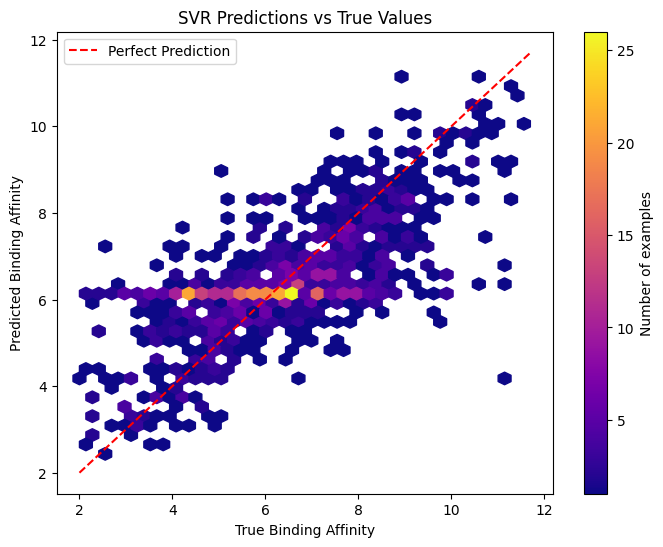

In [9]:
# Plot hexbin of true vs. predicted values
import matplotlib.pyplot as plt


# Create hexbin plot
plt.figure(figsize=(8, 6))
hb = plt.hexbin(y_test, yPred, gridsize=35, cmap='plasma', mincnt=1)

# Add a colorbar to indicate density
cb = plt.colorbar(hb)
cb.set_label('Number of examples')

# Add labels and title
plt.xlabel("True Binding Affinity")
plt.ylabel("Predicted Binding Affinity")
plt.title("SVR Predictions vs True Values")

# Add a diagonal line y = x to show the ideal prediction
min_val = min(min(y_test), min(yPred))
max_val = max(max(y_test), max(yPred))
plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', label='Perfect Prediction')

# Add legend
plt.legend()

# Show the plot
plt.show()